# LPA Comparison: Implementation from Scratch vs NetworkX

Metrics compared: number of communities, community size distribution, modularity, NMI between partitions, runtime, and stability across runs.

In [1]:
%matplotlib inline

import time
import random
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import scipy.sparse as sp
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import modularity, label_propagation_communities

In [2]:
BASE_DIR = Path().resolve()
while not (BASE_DIR / "data").exists() and BASE_DIR.parent != BASE_DIR:
    BASE_DIR = BASE_DIR.parent

NPZ_PATH = (
    BASE_DIR / "data" / "graphs" / "adjacency_sparse"
    / "inter_to_ict_chb01_03_2980_3010_adjacency_sparse.npz"
)

THRESHOLD = 0.2
N_RUNS    = 10

print(f"Loading: {NPZ_PATH}")

Loading: /Users/antoniaspoerk/Desktop/Digital Neuroscience /Social Media Analytics/epilepsy_pediatrics_EEG/data/graphs/adjacency_sparse/inter_to_ict_chb01_03_2980_3010_adjacency_sparse.npz


In [3]:
A = sp.load_npz(NPZ_PATH).tocsr()
A.data[A.data < THRESHOLD] = 0
A.eliminate_zeros()

G = nx.from_scipy_sparse_array(A)
print(f"Nodes : {G.number_of_nodes():,}")
print(f"Edges : {G.number_of_edges():,}")

Nodes : 176,640
Edges : 1,943,040


## Helper functions

In [4]:
def compute_nmi(labels_a, labels_b):
    """Fast NMI using a sparse joint-count approach — O(n) time and space."""
    a, b = np.asarray(labels_a), np.asarray(labels_b)
    n = len(a)

    _, a_idx = np.unique(a, return_inverse=True)
    _, b_idx = np.unique(b, return_inverse=True)

    joint = Counter(zip(a_idx.tolist(), b_idx.tolist()))
    pa = np.bincount(a_idx) / n
    pb = np.bincount(b_idx) / n

    mi = sum(
        cnt / n * np.log((cnt / n) / (pa[i] * pb[j]))
        for (i, j), cnt in joint.items()
    )
    ha = -(pa[pa > 0] * np.log(pa[pa > 0])).sum()
    hb = -(pb[pb > 0] * np.log(pb[pb > 0])).sum()
    return 2 * mi / (ha + hb) if ha + hb > 0 else 1.0


def communities_to_labels(n_nodes, partition):
    labels = np.empty(n_nodes, dtype=int)
    for comm_id, community in enumerate(partition):
        for node in community:
            labels[node] = comm_id
    return labels


def labels_to_sets(labels):
    comms = defaultdict(set)
    for node, lab in enumerate(labels):
        comms[lab].add(node)
    return list(comms.values())

## Custom LPA

In [5]:
def custom_lpa(G, max_iter=100, seed=None):
    if seed is not None:
        random.seed(seed)
    labels = {node: node for node in G.nodes()}

    for _ in range(max_iter):
        changes = 0
        nodes = list(G.nodes())
        random.shuffle(nodes)
        for node in nodes:
            neighbour_labels = [labels[n] for n in G.neighbors(node)]
            if not neighbour_labels:
                continue
            new_label = Counter(neighbour_labels).most_common(1)[0][0]
            if labels[node] != new_label:
                labels[node] = new_label
                changes += 1
        if changes == 0:
            break

    communities = defaultdict(set)
    for node, label in labels.items():
        communities[label].add(node)
    return list(communities.values())

In [6]:
print(f"Running custom LPA {N_RUNS} times ...")
custom_runs  = []
custom_times = []

for i in range(N_RUNS):
    t0 = time.perf_counter()
    partition = custom_lpa(G, seed=i)
    custom_times.append(time.perf_counter() - t0)
    custom_runs.append(communities_to_labels(G.number_of_nodes(), partition))
    print(f"  run {i+1}: {len(partition)} communities  ({custom_times[-1]:.2f}s)")

print(f"\nMean runtime: {np.mean(custom_times):.2f}s")

Running custom LPA 10 times ...
  run 1: 7680 communities  (3.07s)
  run 2: 7680 communities  (2.85s)
  run 3: 7680 communities  (2.92s)
  run 4: 7680 communities  (2.74s)
  run 5: 7680 communities  (2.85s)
  run 6: 7680 communities  (2.96s)
  run 7: 7680 communities  (2.71s)
  run 8: 7680 communities  (2.62s)
  run 9: 7680 communities  (2.64s)
  run 10: 7680 communities  (2.62s)

Mean runtime: 2.80s


## NetworkX LPA

In [7]:
print(f"Running NetworkX LPA {N_RUNS} times ...")
nx_runs  = []
nx_times = []

for i in range(N_RUNS):
    t0 = time.perf_counter()
    partition = list(label_propagation_communities(G))
    nx_times.append(time.perf_counter() - t0)
    nx_runs.append(communities_to_labels(G.number_of_nodes(), partition))
    print(f"  run {i+1}: {len(partition)} communities  ({nx_times[-1]:.2f}s)")

print(f"\nMean runtime: {np.mean(nx_times):.2f}s")

Running NetworkX LPA 10 times ...
  run 1: 7680 communities  (1.82s)
  run 2: 7680 communities  (1.84s)
  run 3: 7680 communities  (1.80s)
  run 4: 7680 communities  (1.84s)
  run 5: 7680 communities  (1.83s)
  run 6: 7680 communities  (1.84s)
  run 7: 7680 communities  (1.81s)
  run 8: 7680 communities  (1.82s)
  run 9: 7680 communities  (1.98s)
  run 10: 7680 communities  (1.91s)

Mean runtime: 1.85s


## Comparison

In [8]:
Q_custom = modularity(G, labels_to_sets(custom_runs[0]))
Q_nx     = modularity(G, labels_to_sets(nx_runs[0]))

custom_stability = np.mean([
    compute_nmi(custom_runs[0], custom_runs[i]) for i in range(1, N_RUNS)
])
nx_stability = np.mean([
    compute_nmi(nx_runs[0], nx_runs[i]) for i in range(1, N_RUNS)
])

nmi_between = compute_nmi(custom_runs[0], nx_runs[0])

print(f"{'Metric':<35} {'Custom LPA':>12} {'NetworkX LPA':>14}")
print("-" * 63)
print(f"{'Communities (run 1)':<35} {len(labels_to_sets(custom_runs[0])):>12} {len(labels_to_sets(nx_runs[0])):>14}")
print(f"{'Modularity':<35} {Q_custom:>12.4f} {Q_nx:>14.4f}")
print(f"{'Stability (mean NMI across runs)':<35} {custom_stability:>12.4f} {nx_stability:>14.4f}")
print(f"{'Mean runtime (s)':<35} {np.mean(custom_times):>12.2f} {np.mean(nx_times):>14.2f}")
print("-" * 63)
print(f"NMI between implementations (run 1): {nmi_between:.4f}")

Metric                                Custom LPA   NetworkX LPA
---------------------------------------------------------------
Communities (run 1)                         7680           7680
Modularity                                0.9999         0.9999
Stability (mean NMI across runs)          1.0000         1.0000
Mean runtime (s)                            2.80           1.85
---------------------------------------------------------------
NMI between implementations (run 1): 1.0000


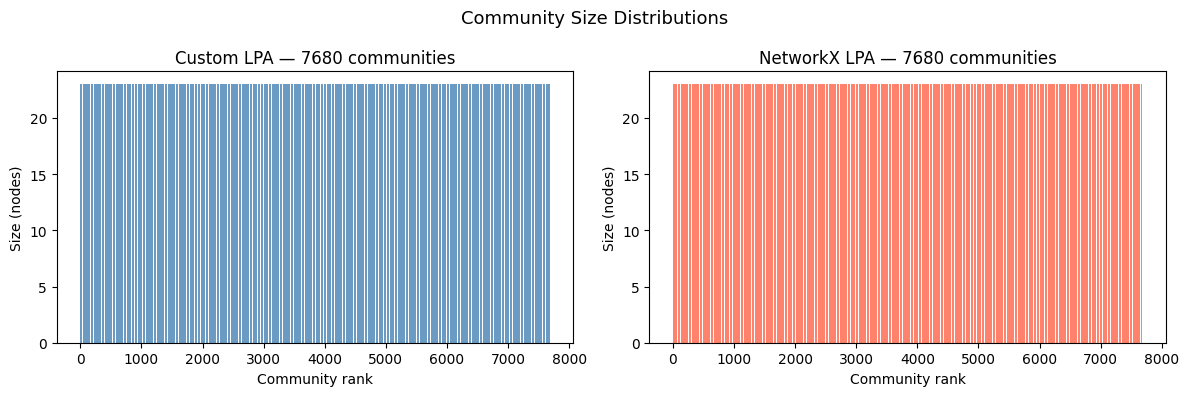

In [9]:
custom_sizes = sorted([len(c) for c in labels_to_sets(custom_runs[0])], reverse=True)
nx_sizes     = sorted([len(c) for c in labels_to_sets(nx_runs[0])],     reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, sizes, title, color in [
    (axes[0], custom_sizes, "Custom LPA",   "steelblue"),
    (axes[1], nx_sizes,     "NetworkX LPA", "tomato"),
]:
    ax.bar(range(len(sizes)), sizes, color=color, alpha=0.8)
    ax.set_xlabel("Community rank")
    ax.set_ylabel("Size (nodes)")
    ax.set_title(f"{title} — {len(sizes)} communities")

plt.suptitle("Community Size Distributions", fontsize=13)
plt.tight_layout()
plt.show()

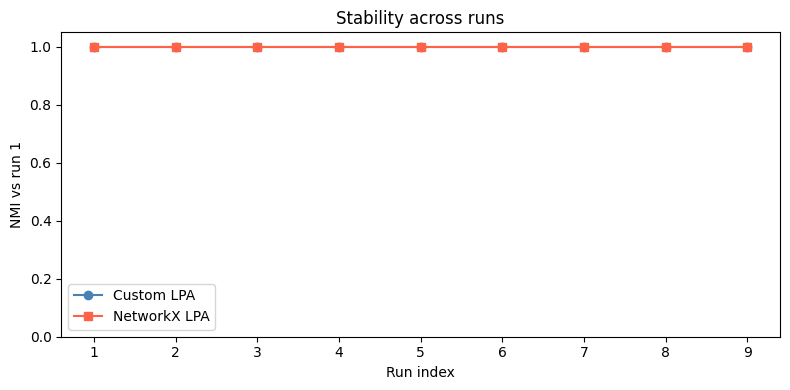

In [10]:
custom_nmi_runs = [compute_nmi(custom_runs[0], r) for r in custom_runs[1:]]
nx_nmi_runs     = [compute_nmi(nx_runs[0],     r) for r in nx_runs[1:]]

fig, ax = plt.subplots(figsize=(8, 4))
run_ids = range(1, N_RUNS)
ax.plot(run_ids, custom_nmi_runs, 'o-', color='steelblue', label='Custom LPA')
ax.plot(run_ids, nx_nmi_runs,     's-', color='tomato',    label='NetworkX LPA')
ax.set_xlabel("Run index")
ax.set_ylabel("NMI vs run 1")
ax.set_ylim(0, 1.05)
ax.set_title("Stability across runs")
ax.legend()
plt.tight_layout()
plt.show()